MLP Gridworld Experiment
Goal: Train an MLP to predict o_t+1 from o_t and a_t, and examine whether it is sufficient to properly distinguish from two observationally equal positions

Results observation: The NN is able predict o_t+1 better than assuming no change (the baseline loss), but has a tendency to overfit when past 1000 epochs.

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Imports

In [16]:
from gridworld import GridWorld, Agent
import sys
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

print(sys.executable)
print(torch.__version__)

/home/seblee/miniconda3/envs/main/bin/python
2.14.0+cu130


State variables

In [17]:

HEIGHT = 20
WIDTH = 25
VIEW_SIZE = 5

START_X = 6
START_Y = 6
START_DIRECTION = 2

N_STEPS = 500

ACTION_PROBS = [0.6, 0.15, 0.15, 0.1]

SEED = 42

Gridworld Creation

In [18]:
grid = GridWorld(HEIGHT, WIDTH)
grid.add_rectangle_region(5, 10, 5, 20)
grid.add_rectangle_region(10, 15, 10, 15)
grid.add_square_shape(6, 6, 3, 7)
grid.add_triangle_shape(6, 11, 3, 0, 6)
grid.add_single_shape(7, 17, 5)
grid.add_single_shape(6, 16, 5)
grid.add_single_shape(6, 18, 5)
grid.add_single_shape(8, 16, 5)
grid.add_single_shape(8, 18, 5)
grid.add_rectangle_shape(11, 12, 3, 1, 3)
grid.add_rectangle_shape(12, 11, 1, 3, 4)


Trajectory Generation Function

In [19]:
def generate_trajectory(grid, start_x, start_y, start_direction, view_size, n_steps, seed):
    
    agent = Agent(start_x, start_y, view_size, grid, start_direction)   #Create agent

    rng = np.random.default_rng(seed)

    for i in range(n_steps):                                            #Agent random walk
        action = rng.choice([0, 1, 2, 3], p=[0.6, 0.15, 0.15, 0.1])

        if action == 0:
            agent.move()
            #print(f"moved towards {agent.direction}")
        elif action == 3:
            agent.stop()
            #print("stopped")
        else:

            agent.rotate(action)
            #print(f"rotated towards {agent.direction}")
        observation = agent.observe()
        #print(pd.DataFrame(observation))

    #print(agent.states)
    print(len(agent.states))
    print(len(agent.observations))
    print(len(agent.actions))

    return agent

Trajectory Data Formatting Function

In [20]:
def prepare_data(agent):                                                                #Conversion to tensors
    observations = torch.tensor(
        np.array(agent.observations),
        dtype = torch.float32
    )
    actions = torch.tensor(
        agent.actions, 
        dtype = torch.long
    )
    states = torch.tensor(
        agent.states,
        dtype = torch.long
    )
    print(observations.shape)
    print(actions.shape)
    print(states.shape)
    observations = observations.flatten(start_dim = 1)
    print(observations.shape)
    actions_onehot = torch.nn.functional.one_hot(
        actions,
        num_classes = 4
    ).float()
    print(actions_onehot.shape)
    input_obs = observations[:-1]
    target_obs = observations[1:]
    inputs = torch.cat(
        (input_obs, actions_onehot),
        dim = 1
    )
    print("input observations: ", input_obs.shape)
    print("actions: ", actions_onehot.shape)
    print("NN inputs: ", inputs.shape)
    print("targets: ", target_obs.shape)
    
    return inputs, target_obs

NN Model Creation Function

In [21]:

def model_creation(input, output, hidden_size):

    model = nn.Sequential(
        nn.Linear(trainer_data_inputs.shape[1], hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, output.shape[1])
    )
    return model

Model Evaluation Function

In [22]:

def model_evaluation(model, observation, inputs, name):

    loss_fn = nn.MSELoss()
    model.eval()
    with torch.no_grad():
        prediction = model(inputs)
        test_loss = loss_fn(prediction, observation)
    print(test_loss.item())

    print(f"Test loss, {name}: ", test_loss.item())

    return test_loss.item()

Baseline Evaluation Function

In [23]:

def baseline_evaluation(inputs, targets):
    observation_size = targets.shape[1]

    baseline_prediction = inputs[:, :observation_size]
    loss_fn = nn.MSELoss()
    baseline_loss = loss_fn(baseline_prediction, targets)

    print("Baseline loss: ", baseline_loss.item())


Model Training Function

In [24]:

def model_training(model, input, output):

    loss_fn = nn.MSELoss()

    loss_history = []

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    model.train()

    trainer_error_log = []
    validator_error_log = []
    epochs_recorded = []
    for epoch in range(3000):
        optimizer.zero_grad()
        prediction = model(input)

        loss = loss_fn(prediction, output)
        loss_history.append(loss.item())
        loss.backward()

        optimizer.step()

        if epoch % 100 == 0:
            #print(epoch, loss.item())
            trainer_error = model_evaluation(model_NN, trainer_data_target_obs, trainer_data_inputs, "trainer")
            validator_error = model_evaluation(model_NN, validator_data_target_obs, validator_data_inputs, "validator")
            trainer_error_log.append(trainer_error)
            validator_error_log.append(validator_error)
            epochs_recorded.append(epoch)

    plt.plot(epochs_recorded, trainer_error_log, label = "training")
    plt.plot(epochs_recorded, validator_error_log, label = "test")
    plt.xlabel("epoch")
    plt.ylabel("error")
    plt.legend()
    plt.show()

    return loss_history

NN Training and Validation

501
501
500
torch.Size([501, 5, 5])
torch.Size([500])
torch.Size([501, 3])
torch.Size([501, 25])
torch.Size([500, 4])
input observations:  torch.Size([500, 25])
actions:  torch.Size([500, 4])
NN inputs:  torch.Size([500, 29])
targets:  torch.Size([500, 25])
201
201
200
torch.Size([201, 5, 5])
torch.Size([200])
torch.Size([201, 3])
torch.Size([201, 25])
torch.Size([200, 4])
input observations:  torch.Size([200, 25])
actions:  torch.Size([200, 4])
NN inputs:  torch.Size([200, 29])
targets:  torch.Size([200, 25])
4.344153881072998
Test loss, trainer:  4.344153881072998
7.458619594573975
Test loss, validator:  7.458619594573975
2.363030195236206
Test loss, trainer:  2.363030195236206
4.137618541717529
Test loss, validator:  4.137618541717529
1.986182451248169
Test loss, trainer:  1.986182451248169
3.889761209487915
Test loss, validator:  3.889761209487915
1.6811598539352417
Test loss, trainer:  1.6811598539352417
3.786933660507202
Test loss, validator:  3.786933660507202
1.4311569929122925

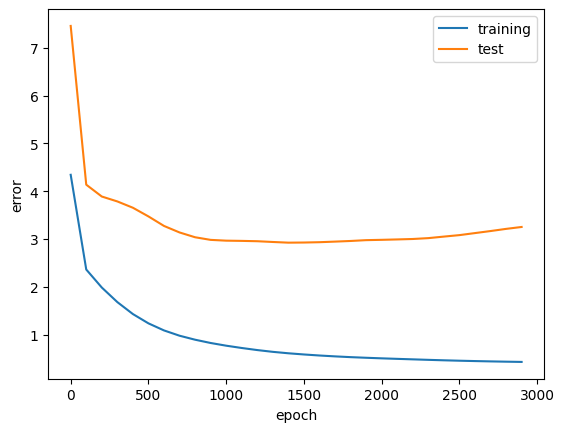

0.4244871735572815
Test loss, trainer:  0.4244871735572815
3.311199903488159
Test loss, validator:  3.311199903488159
Baseline loss:  7.290800094604492


In [25]:

trainer_agent = generate_trajectory(grid, START_X, START_Y, START_DIRECTION, VIEW_SIZE, N_STEPS, SEED)
trainer_data_inputs, trainer_data_target_obs = prepare_data(trainer_agent)

TEST_SEED = 123
TEST_STEPS = 200

validator_agent = generate_trajectory(grid, START_X, START_Y, START_DIRECTION, VIEW_SIZE, TEST_STEPS, TEST_SEED)
validator_data_inputs, validator_data_target_obs = prepare_data(validator_agent)

INPUT_SIZE = trainer_data_inputs.shape[1]
OUTPUT_SIZE = trainer_data_target_obs.shape[1]
HIDDEN_SIZE = 64     


model_NN = model_creation(trainer_data_inputs, trainer_data_target_obs, HIDDEN_SIZE)
loss_history = model_training(model_NN, trainer_data_inputs, trainer_data_target_obs)


model_evaluation(model_NN, trainer_data_target_obs, trainer_data_inputs, "trainer")
model_evaluation(model_NN, validator_data_target_obs, validator_data_inputs, "validator")
baseline_evaluation(validator_data_inputs, validator_data_target_obs)



validator Error per Action Type

There are t predictions, t + 1 observations and t actions
predictions start from 

In [26]:
validator_agent_actions = validator_agent.actions
trainer_agent_actions = trainer_agent.actions

validator_action_move = []
validator_action_left = []
validator_action_right = []
validator_action_stop = []
baseline_validator_action_move = []
baseline_validator_action_left = []
baseline_validator_action_right = []
baseline_validator_action_stop = []
trainer_action_move = []
trainer_action_left = []
trainer_action_right = []
trainer_action_stop = []

model_NN.eval()

with torch.no_grad():
    validator_pred_obs = model_NN(validator_data_inputs)
    trainer_pred_obs = model_NN(trainer_data_inputs)

loss_fn = nn.MSELoss(reduction = "none")


validator_loss = loss_fn(validator_data_target_obs, validator_pred_obs)
trainer_loss = loss_fn(trainer_data_target_obs, trainer_pred_obs)

observations_size = validator_data_target_obs.shape[1]
validator_data_target_obs_minusone = validator_data_inputs[:, :observations_size]

baseline_loss = loss_fn(validator_data_target_obs, validator_data_target_obs_minusone)

avg_validator_loss = validator_loss.mean(dim = 1)
avg_trainer_loss = trainer_loss.mean(dim = 1)

i = 0
for actions in validator_agent_actions:
    if actions == 0:
        validator_action_move.append(avg_validator_loss[i])
        baseline_validator_action_move.append(baseline_loss[i])
    elif actions == 1:
        validator_action_left.append(avg_validator_loss[i])
        baseline_validator_action_left.append(baseline_loss[i])
    elif actions == 2:
        validator_action_right.append(avg_validator_loss[i])
        baseline_validator_action_right.append(baseline_loss[i])
    elif actions == 3:
        validator_action_stop.append(avg_validator_loss[i])
        baseline_validator_action_stop.append(baseline_loss[i])
    i += 1

j = 0
for actions in trainer_agent_actions:
    if actions == 0:
        trainer_action_move.append(avg_trainer_loss[j])
    elif actions == 1:
        trainer_action_left.append(avg_trainer_loss[j])
    elif actions == 2:
        trainer_action_right.append(avg_trainer_loss[j])
    elif actions == 3:
        trainer_action_stop.append(avg_trainer_loss[j])
    j += 1

validator_move_loss = torch.stack(validator_action_move).mean()
validator_left_loss = torch.stack(validator_action_left).mean()
validator_right_loss = torch.stack(validator_action_right).mean()
validator_stop_loss = torch.stack(validator_action_stop).mean()
trainer_move_loss = torch.stack(trainer_action_move).mean()
trainer_left_loss = torch.stack(trainer_action_left).mean()
trainer_right_loss = torch.stack(trainer_action_right).mean()
trainer_stop_loss = torch.stack(trainer_action_stop).mean()
baseline_move_loss = torch.stack(baseline_validator_action_move).mean()
baseline_left_loss = torch.stack(baseline_validator_action_left).mean()
baseline_right_loss = torch.stack(baseline_validator_action_right).mean()
baseline_stop_loss = torch.stack(baseline_validator_action_stop).mean()

print(f"move loss: {validator_move_loss}, {len(validator_action_move)}")
print(f"left loss: {validator_left_loss}, {len(validator_action_left)}")
print(f"right loss: {validator_right_loss}, {len(validator_action_right)}")
print(f"stop loss: {validator_stop_loss}, {len(validator_action_stop)}")

print(f"trainer move loss: {trainer_move_loss}, {len(trainer_action_move)}")
print(f"trainer left loss: {trainer_left_loss}, {len(trainer_action_left)}")
print(f"trainer right loss: {trainer_right_loss}, {len(trainer_action_right)}")
print(f"trainer stop loss: {trainer_stop_loss}, {len(trainer_action_stop)}")

print(f"baseline_move loss: {baseline_move_loss}, {len(baseline_validator_action_move)}")
print(f"baseline_left loss: {baseline_left_loss}, {len(baseline_validator_action_left)}")
print(f"baseline_right loss: {baseline_right_loss}, {len(baseline_validator_action_right)}")
print(f"baseline_stop loss: {baseline_stop_loss}, {len(baseline_validator_action_stop)}")


validator_global_avg_loss = (validator_move_loss * len(validator_action_move) + validator_left_loss * len(validator_action_left) + validator_right_loss * len(validator_action_right) + validator_stop_loss * len(validator_action_stop)) / 200
trainer_global_avg_loss = (trainer_move_loss * len(trainer_action_move) + trainer_left_loss * len(trainer_action_left) + trainer_right_loss * len(trainer_action_right) + trainer_stop_loss * len(trainer_action_stop)) / 500

print(f"validator Global Average Loss: {validator_global_avg_loss}")
print(f"Trainer Global Average Loss: {trainer_global_avg_loss}")



move loss: 1.690226674079895, 127
left loss: 6.603596210479736, 25
right loss: 6.169003009796143, 31
stop loss: 5.367778301239014, 17
trainer move loss: 0.1583288460969925, 300
trainer left loss: 1.1006245613098145, 76
trainer right loss: 0.7630646228790283, 79
trainer stop loss: 0.46256396174430847, 45
baseline_move loss: 5.4859843254089355, 127
baseline_left loss: 13.28320026397705, 25
baseline_right loss: 13.850322723388672, 31
baseline_stop loss: 0.0, 17
validator Global Average Loss: 3.311199903488159
Trainer Global Average Loss: 0.4244872033596039


A Standard NN is memoryless, so if for two different states, the same observation is presented and the same action is chosen, the input to the NN are effectively the same, with no distinguishability. The next goal is to show that this is an issue with standard MLPs.

Find scenarios where (o_t, a_t) are equal but o_t+1 are different at the next step. then compare the predicted o_t+1 and see how similar they are one to the other

In [27]:
trainer_validator_inputs = torch.cat((trainer_data_inputs, validator_data_inputs), dim = 0)
equal_input_pairs = []

groups = {}

for i in range(len(trainer_validator_inputs)):
    key = tuple(trainer_validator_inputs[i].tolist())

    if key not in groups:
        groups[key] = []

    groups[key].append(i)

multiinput_count = 0
oneinput_count = 0
for key, number in groups.items():
    if len(number) > 1:
        print(number)
        multiinput_count += 1
    else:
        oneinput_count += 1
    if len(number) == 2:
        print(f"occurences: {len(number)}")

        key_tensor = torch.tensor(key)
        observation = key_tensor[:25].reshape(5, 5)
        action = key_tensor[25:]

        #print(observation)
        #print(action)

#print(multiinput_count)
#print(oneinput_count)


[2, 6, 115]
[4, 108, 110, 111, 112, 113, 114, 436, 437]
[5, 109]
occurences: 2
[7, 645]
occurences: 2
[8, 660]
occurences: 2
[9, 501]
occurences: 2
[10, 502]
occurences: 2
[14, 503]
occurences: 2
[15, 504]
occurences: 2
[18, 20]
occurences: 2
[21, 33]
occurences: 2
[23, 241]
occurences: 2
[27, 28, 51, 56, 57, 58, 59, 289, 301, 302, 303, 308, 309, 310, 311, 312, 313, 314, 315, 316, 327, 363, 380, 388, 391, 392, 397, 398, 399, 400, 463, 464, 488, 489, 519, 520, 521, 522, 523, 524, 525, 526, 604, 629, 630, 698, 699]
[29, 54, 60, 299, 317, 325, 328, 364, 367, 393, 465, 490, 515, 527, 534, 605, 631]
[31, 295, 296]
[37, 202, 562]
[39, 447]
occurences: 2
[40, 448]
occurences: 2
[41, 425]
occurences: 2
[42, 424]
occurences: 2
[43, 603]
occurences: 2
[44, 52, 290, 304, 342, 382, 389, 402, 512, 537, 665]
[46, 443]
occurences: 2
[47, 444]
occurences: 2
[48, 445]
occurences: 2
[61, 124]
occurences: 2
[62, 125]
occurences: 2
[63, 72, 79, 82, 138, 261, 278]
[64, 77, 80, 86, 119, 274, 576]
[65, 66, 6

Consider which equal scenarios contain a different next observation, and also compare with predicted observation

In [28]:
trainer_validator_target_obs = torch.cat((trainer_data_target_obs, validator_data_target_obs), dim = 0)


for key, indices in groups.items():
    if len(indices) > 1:
        matching_set = set()
        for i in indices:
            target_key = tuple(trainer_validator_target_obs[i].tolist())
            matching_set.add(target_key)

        print(f"Occurences: {len(indices)}")
        print(f"Matching sets: {(len(matching_set))}")
        print(f"Indices: {indices}")





Occurences: 3
Matching sets: 2
Indices: [2, 6, 115]
Occurences: 9
Matching sets: 1
Indices: [4, 108, 110, 111, 112, 113, 114, 436, 437]
Occurences: 2
Matching sets: 1
Indices: [5, 109]
Occurences: 2
Matching sets: 1
Indices: [7, 645]
Occurences: 2
Matching sets: 2
Indices: [8, 660]
Occurences: 2
Matching sets: 1
Indices: [9, 501]
Occurences: 2
Matching sets: 1
Indices: [10, 502]
Occurences: 2
Matching sets: 1
Indices: [14, 503]
Occurences: 2
Matching sets: 1
Indices: [15, 504]
Occurences: 2
Matching sets: 1
Indices: [18, 20]
Occurences: 2
Matching sets: 1
Indices: [21, 33]
Occurences: 2
Matching sets: 1
Indices: [23, 241]
Occurences: 47
Matching sets: 1
Indices: [27, 28, 51, 56, 57, 58, 59, 289, 301, 302, 303, 308, 309, 310, 311, 312, 313, 314, 315, 316, 327, 363, 380, 388, 391, 392, 397, 398, 399, 400, 463, 464, 488, 489, 519, 520, 521, 522, 523, 524, 525, 526, 604, 629, 630, 698, 699]
Occurences: 17
Matching sets: 11
Indices: [29, 54, 60, 299, 317, 325, 328, 364, 367, 393, 465, 490, 